# Transfer Learning - Morphological Segmentation

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)

## Config

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
EPOCHS = 30
SAVE_EVERY = 5
SUBSET_PERCENTAGE = 50

ROOT = Path('/content/drive/MyDrive/Research_Project/Plant_Diseases')
DATASET_ROOT = ROOT / 'Dataset_Split_Morphological'
OUTPUTS_DIR = ROOT / 'outputs'
MODELS_DIR = OUTPUTS_DIR / 'models_morphological'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Models will be saved to: {MODELS_DIR}")
print(f"Save checkpoint every {SAVE_EVERY} epochs")
print(f"Using {SUBSET_PERCENTAGE}% of dataset")

Models will be saved to: /content/drive/MyDrive/Research_Project/Plant_Diseases/outputs/models_morphological
Save checkpoint every 5 epochs
Using 50% of dataset


## Custom Callback

In [4]:
class SaveEveryNEpochs(tf.keras.callbacks.Callback):
    def __init__(self, save_every, save_dir, model_name):
        super().__init__()
        self.save_every = save_every
        self.save_dir = Path(save_dir)
        self.model_name = model_name
        self.best_val_acc = 0.0

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.save_every == 0:
            path = self.save_dir / f'{self.model_name}_epoch_{epoch + 1:02d}.keras'
            self.model.save(str(path))
            print(f"Saved checkpoint: {path.name}")

        if logs and logs.get('val_accuracy', 0) > self.best_val_acc:
            self.best_val_acc = logs['val_accuracy']
            path = self.save_dir / f'{self.model_name}_best_epoch_{epoch + 1:02d}.keras'
            self.model.save(str(path))
            print(f"Saved best model: {path.name} (val_acc={self.best_val_acc:.4f})")

## Load Datasets & Weights

In [5]:
with open(OUTPUTS_DIR / 'class_names.json', 'r') as f:
    class_names = json.load(f)

with open(OUTPUTS_DIR / 'class_weights.pkl', 'rb') as f:
    class_weights = pickle.load(f)

NUM_CLASSES = len(class_names)
print(f"Classes: {NUM_CLASSES}")
print(f"Class weights loaded")

Classes: 23
Class weights loaded


In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal', seed=SEED),
    tf.keras.layers.RandomRotation(0.1, seed=SEED),
])

def load_dataset(split='train', augment=False, subset_percent=None):
    if subset_percent is None:
        subset_percent = SUBSET_PERCENTAGE

    split_dir = DATASET_ROOT / split

    ds = tf.keras.utils.image_dataset_from_directory(
        split_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        class_names=class_names,
        seed=SEED,
        shuffle=(split == 'train')
    )

    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE)

    if augment and split == 'train':
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    if subset_percent < 100:
        # Unbatch to ensure all classes represented
        unbatched = ds.unbatch()
        # Count total samples
        total_samples = len(list(split_dir.glob('*/*.jpg'))) + len(list(split_dir.glob('*/*.png'))) + len(list(split_dir.glob('*/*.jpeg')))
        samples_to_take = max(NUM_CLASSES, int(total_samples * subset_percent / 100))
        unbatched = unbatched.shuffle(buffer_size=10000, seed=SEED).take(samples_to_take)
        ds = unbatched.batch(BATCH_SIZE)
        print(f'{split}: Taking ~{samples_to_take} images ({subset_percent}%)')

    ds = ds.cache().prefetch(tf.data.AUTOTUNE)
    return ds

def load_dataset_efficientnet(split='train', augment=False, subset_percent=None):
    if subset_percent is None:
        subset_percent = SUBSET_PERCENTAGE

    split_dir = DATASET_ROOT / split

    ds = tf.keras.utils.image_dataset_from_directory(
        split_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        class_names=class_names,
        seed=SEED,
        shuffle=(split == 'train')
    )

    # EfficientNetB0 preprocessing on [0,255]
    from tensorflow.keras.applications.efficientnet import preprocess_input
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)

    if augment and split == 'train':
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    if subset_percent < 100:
        # Unbatch to ensure all classes represented
        unbatched = ds.unbatch()
        # Count total samples
        total_samples = len(list(split_dir.glob('*/*.jpg'))) + len(list(split_dir.glob('*/*.png'))) + len(list(split_dir.glob('*/*.jpeg')))
        samples_to_take = max(NUM_CLASSES, int(total_samples * subset_percent / 100))
        unbatched = unbatched.shuffle(buffer_size=10000, seed=SEED).take(samples_to_take)
        ds = unbatched.batch(BATCH_SIZE)

    ds = ds.cache().prefetch(tf.data.AUTOTUNE)
    return ds

## MobileNetV2 - Baseline

In [7]:
def build_mobilenetv2():
    base = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
    base.trainable = False

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.7)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return models.Model(inputs, outputs)

mobilenetv2_model = build_mobilenetv2()
mobilenetv2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("MobileNetV2 model built and compiled")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 model built and compiled


In [8]:
train_ds = load_dataset('train', augment=True, subset_percent=SUBSET_PERCENTAGE)
val_ds = load_dataset('val', augment=False, subset_percent=SUBSET_PERCENTAGE)
test_ds = load_dataset('test', augment=False, subset_percent=SUBSET_PERCENTAGE)

print("Datasets loaded")

Found 28628 files belonging to 23 classes.
train: Taking ~968 images (50%)
Found 3551 files belonging to 23 classes.
val: Taking ~126 images (50%)
Found 3547 files belonging to 23 classes.
test: Taking ~122 images (50%)
Datasets loaded


In [9]:
mobilenetv2_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'mobilenetv2_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    SaveEveryNEpochs(save_every=SAVE_EVERY, save_dir=MODELS_DIR, model_name='mobilenetv2')
]

print("Training MobileNetV2...\n")
mobilenetv2_history = mobilenetv2_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=mobilenetv2_callbacks,
    verbose=1
)

Training MobileNetV2...

Epoch 1/30
     61/Unknown 2298s 3s/step - accuracy: 0.1506 - loss: 3.8901Saved best model: mobilenetv2_best_epoch_01.keras (val_acc=0.5556)
61/61 ━━━━━━━━━━━━━━━━━━━━ 3065s 16s/step - accuracy: 0.2304 - loss: 3.4485 - val_accuracy: 0.5556 - val_loss: 1.5132 - learning_rate: 0.0010
Epoch 2/30
59/61 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5320 - loss: 1.6771Saved best model: mobilenetv2_best_epoch_02.keras (val_acc=0.6825)
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5186 - loss: 1.7339 - val_accuracy: 0.6825 - val_loss: 1.1016 - learning_rate: 0.0010
Epoch 3/30
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6185 - loss: 1.2800Saved best model: mobilenetv2_best_epoch_03.keras (val_acc=0.7460)
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.6374 - loss: 1.2618 - val_accuracy: 0.7460 - val_loss: 0.8996 - learning_rate: 0.0010
Epoch 4/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6983 - loss: 0.9981 - val_accuracy: 0.7381 - 

## EfficientNetB0 - Phase 1

In [10]:
train_ds_eff = load_dataset_efficientnet('train', augment=True, subset_percent=SUBSET_PERCENTAGE)
val_ds_eff = load_dataset_efficientnet('val', augment=False, subset_percent=SUBSET_PERCENTAGE)
test_ds_eff = load_dataset_efficientnet('test', augment=False, subset_percent=SUBSET_PERCENTAGE)

Found 28628 files belonging to 23 classes.
Found 3551 files belonging to 23 classes.
Found 3547 files belonging to 23 classes.


In [11]:
def build_efficientnetb0():
    base = EfficientNetB0(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
    base.trainable = False

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return models.Model(inputs, outputs)

efficientnetb0_model = build_efficientnetb0()
efficientnetb0_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("EfficientNetB0 model built and compiled")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 model built and compiled


In [12]:
p1_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'efficientnetb0_phase1.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    SaveEveryNEpochs(save_every=SAVE_EVERY, save_dir=MODELS_DIR, model_name='efficientnetb0_phase1')
]

print("Phase 1: Training frozen base (15 epochs)...\n")
efficientnetb0_history_p1 = efficientnetb0_model.fit(
    train_ds_eff,
    validation_data=val_ds_eff,
    epochs=15,
    class_weight=class_weights,
    callbacks=p1_callbacks,
    verbose=1
)

Phase 1: Training frozen base (15 epochs)...

Epoch 1/15
     61/Unknown 123s 361ms/step - accuracy: 0.0554 - loss: 3.7425Saved best model: efficientnetb0_phase1_best_epoch_01.keras (val_acc=0.1508)
61/61 ━━━━━━━━━━━━━━━━━━━━ 152s 853ms/step - accuracy: 0.0878 - loss: 3.5422 - val_accuracy: 0.1508 - val_loss: 2.8387 - learning_rate: 1.0000e-04
Epoch 2/15
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2545 - loss: 2.4930Saved best model: efficientnetb0_phase1_best_epoch_02.keras (val_acc=0.3968)
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.2634 - loss: 2.4906 - val_accuracy: 0.3968 - val_loss: 2.4690 - learning_rate: 1.0000e-04
Epoch 3/15
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3873 - loss: 2.0038Saved best model: efficientnetb0_phase1_best_epoch_03.keras (val_acc=0.5317)
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.3895 - loss: 2.0484 - val_accuracy: 0.5317 - val_loss: 2.1226 - learning_rate: 1.0000e-04
Epoch 4/15
59/61 ━━━━━━━━━━━━━━━━━━━━ 0s 21m

In [13]:
import tensorflow as tf

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")
for gpu in gpus:
    print(f"  {gpu}")

if len(gpus) > 0:
    print(f"\n✓ Using GPU: {gpus[0].name}")
else:
    print("\n✗ NO GPU detected! Training will be slow.")
    print("In Colab: Runtime → Change runtime type → GPU")

GPUs available: 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

✓ Using GPU: /physical_device:GPU:0


## EfficientNetB0 - Phase 2 (Fine-tuning)

In [14]:
base_model = efficientnetb0_model.get_layer('efficientnetb0')
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

efficientnetb0_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Base model unfrozen (last 20 layers trainable)")

Base model unfrozen (last 20 layers trainable)


In [15]:
p2_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'efficientnetb0_finetuned.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1),
    SaveEveryNEpochs(save_every=SAVE_EVERY, save_dir=MODELS_DIR, model_name='efficientnetb0_phase2')
]

print("Phase 2: Fine-tuning (30 epochs)...\n")
efficientnetb0_history_p2 = efficientnetb0_model.fit(
    train_ds_eff,
    validation_data=val_ds_eff,
    epochs=30,
    class_weight=class_weights,
    callbacks=p2_callbacks,
    verbose=1
)

print(f"\nModels saved to {MODELS_DIR}")

Phase 2: Fine-tuning (30 epochs)...

Epoch 1/30
     61/Unknown 47s 291ms/step - accuracy: 0.4978 - loss: 1.7917Saved best model: efficientnetb0_phase2_best_epoch_01.keras (val_acc=0.7698)
61/61 ━━━━━━━━━━━━━━━━━━━━ 64s 576ms/step - accuracy: 0.4886 - loss: 1.7554 - val_accuracy: 0.7698 - val_loss: 0.8385 - learning_rate: 1.0000e-05
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.5248 - loss: 1.6034 - val_accuracy: 0.7619 - val_loss: 0.9222 - learning_rate: 1.0000e-05
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5434 - loss: 1.4955 - val_accuracy: 0.7698 - val_loss: 0.9705 - learning_rate: 1.0000e-05
Epoch 4/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5630 - loss: 1.3971 - val_accuracy: 0.7619 - val_loss: 0.9863 - learning_rate: 1.0000e-05
Epoch 5/30
59/61 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6099 - loss: 1.2462Saved checkpoint: efficientnetb0_phase2_epoch_05.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.6074 - 

## Test Set Evaluation

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import numpy as np

# Load best models
mobilenetv2_best = tf.keras.models.load_model(str(MODELS_DIR / 'mobilenetv2_best.keras'))
efficientnetb0_best = tf.keras.models.load_model(str(MODELS_DIR / 'efficientnetb0_finetuned.keras'))

print("Best models loaded\n")

# MobileNetV2 evaluation
print("="*60)
print("MobileNetV2 - TEST SET RESULTS")
print("="*60)
mobilenetv2_test_loss, mobilenetv2_test_acc = mobilenetv2_best.evaluate(test_ds, verbose=0)
print(f"Accuracy: {mobilenetv2_test_acc:.4f}")
print(f"Loss: {mobilenetv2_test_loss:.4f}")

# Get predictions for precision, recall, F1
mobilenetv2_preds = mobilenetv2_best.predict(test_ds, verbose=0)
mobilenetv2_pred_classes = np.argmax(mobilenetv2_preds, axis=1)

# Collect true labels from test_ds
mobilenetv2_true_labels = []
for _, labels in test_ds:
    mobilenetv2_true_labels.extend(np.argmax(labels.numpy(), axis=1))
mobilenetv2_true_labels = np.array(mobilenetv2_true_labels)

print("\nPrecision (macro): {:.4f}".format(precision_score(mobilenetv2_true_labels, mobilenetv2_pred_classes, average='macro', zero_division=0)))
print("Recall (macro): {:.4f}".format(recall_score(mobilenetv2_true_labels, mobilenetv2_pred_classes, average='macro', zero_division=0)))
print("F1 (macro): {:.4f}".format(f1_score(mobilenetv2_true_labels, mobilenetv2_pred_classes, average='macro', zero_division=0)))

print("\nPer-class metrics:")
print(classification_report(mobilenetv2_true_labels, mobilenetv2_pred_classes, target_names=class_names, zero_division=0))

# EfficientNetB0 evaluation
print("\n" + "="*60)
print("EfficientNetB0 - TEST SET RESULTS")
print("="*60)
efficientnetb0_test_loss, efficientnetb0_test_acc = efficientnetb0_best.evaluate(test_ds_eff, verbose=0)
print(f"Accuracy: {efficientnetb0_test_acc:.4f}")
print(f"Loss: {efficientnetb0_test_loss:.4f}")

# Get predictions
efficientnetb0_preds = efficientnetb0_best.predict(test_ds_eff, verbose=0)
efficientnetb0_pred_classes = np.argmax(efficientnetb0_preds, axis=1)

# Collect true labels
efficientnetb0_true_labels = []
for _, labels in test_ds_eff:
    efficientnetb0_true_labels.extend(np.argmax(labels.numpy(), axis=1))
efficientnetb0_true_labels = np.array(efficientnetb0_true_labels)

print("\nPrecision (macro): {:.4f}".format(precision_score(efficientnetb0_true_labels, efficientnetb0_pred_classes, average='macro', zero_division=0)))
print("Recall (macro): {:.4f}".format(recall_score(efficientnetb0_true_labels, efficientnetb0_pred_classes, average='macro', zero_division=0)))
print("F1 (macro): {:.4f}".format(f1_score(efficientnetb0_true_labels, efficientnetb0_pred_classes, average='macro', zero_division=0)))

print("\nPer-class metrics:")
print(classification_report(efficientnetb0_true_labels, efficientnetb0_pred_classes, target_names=class_names, zero_division=0))

# Comparison
print("\n" + "="*60)
print("COMPARISON")
print("="*60)
print(f"MobileNetV2 Accuracy: {mobilenetv2_test_acc:.4f}")
print(f"EfficientNetB0 Accuracy: {efficientnetb0_test_acc:.4f}")
print(f"Improvement: {(efficientnetb0_test_acc - mobilenetv2_test_acc)*100:.2f}%")
print(f"\nBest Model: {'EfficientNetB0' if efficientnetb0_test_acc > mobilenetv2_test_acc else 'MobileNetV2'}")
print("="*60)

Best models loaded

MobileNetV2 - TEST SET RESULTS
Accuracy: 0.7295
Loss: 1.1635

Precision (macro): 0.6705
Recall (macro): 0.7347
F1 (macro): 0.6847

Per-class metrics:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.80      0.80      0.80         5
                                 Apple___Black_rot       0.88      0.78      0.82         9
                          Apple___Cedar_apple_rust       1.00      1.00      1.00         2
                                   Apple___healthy       0.67      0.86      0.75         7
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.80      0.80      0.80         5
                       Corn_(maize)___Common_rust_       0.62      1.00      0.77         5
               Corn_(maize)___Northern_Leaf_Blight       0.67      0.40      0.50         5
                            Corn_(maize)___healthy       1.00      0.89      0.94         9
 

## Training Curves

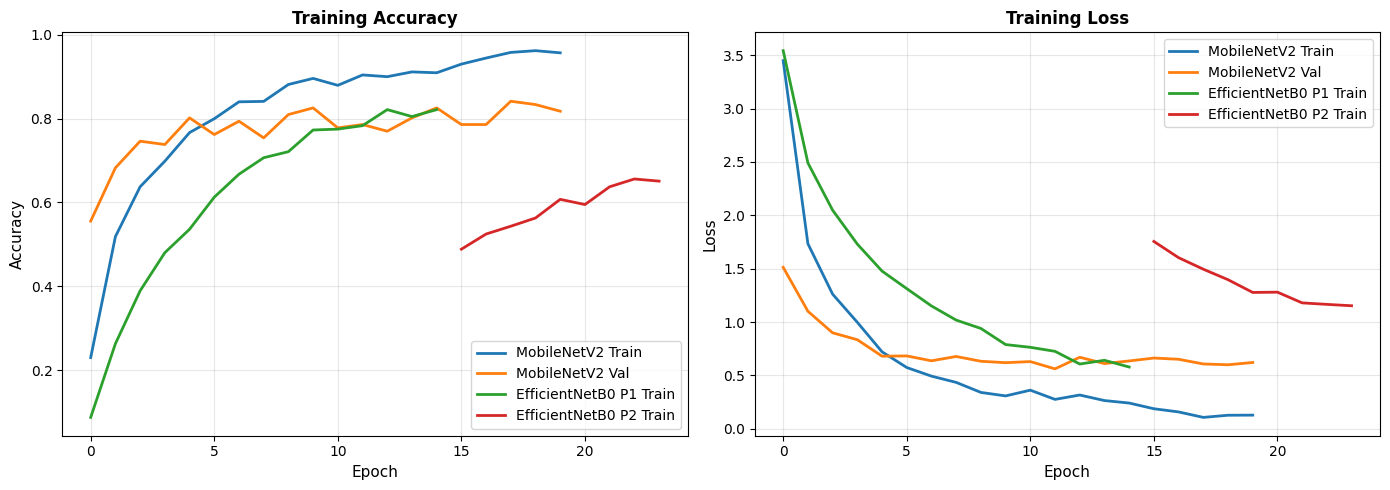

Training curves saved


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mobilenetv2_history.history['accuracy'], label='MobileNetV2 Train', linewidth=2)
axes[0].plot(mobilenetv2_history.history['val_accuracy'], label='MobileNetV2 Val', linewidth=2)
axes[0].plot(efficientnetb0_history_p1.history['accuracy'], label='EfficientNetB0 P1 Train', linewidth=2)
axes[0].plot([len(efficientnetb0_history_p1.history['accuracy']) + i for i in range(len(efficientnetb0_history_p2.history['accuracy']))],
             efficientnetb0_history_p2.history['accuracy'], label='EfficientNetB0 P2 Train', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Training Accuracy', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].plot(mobilenetv2_history.history['loss'], label='MobileNetV2 Train', linewidth=2)
axes[1].plot(mobilenetv2_history.history['val_loss'], label='MobileNetV2 Val', linewidth=2)
axes[1].plot(efficientnetb0_history_p1.history['loss'], label='EfficientNetB0 P1 Train', linewidth=2)
axes[1].plot([len(efficientnetb0_history_p1.history['loss']) + i for i in range(len(efficientnetb0_history_p2.history['loss']))],
             efficientnetb0_history_p2.history['loss'], label='EfficientNetB0 P2 Train', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'training_curves_morphological.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved")

## Save Results

In [18]:
results_df = pd.DataFrame([
    {'Model': 'MobileNetV2', 'Test_Accuracy': mobilenetv2_test_acc, 'Test_Loss': mobilenetv2_test_loss},
    {'Model': 'EfficientNetB0', 'Test_Accuracy': efficientnetb0_test_acc, 'Test_Loss': efficientnetb0_test_loss}
])

results_df.to_csv(OUTPUTS_DIR / 'results_morphological.csv', index=False)
print(f"Results saved to {OUTPUTS_DIR / 'results_morphological.csv'}")
print(results_df.to_string(index=False))

Results saved to /content/drive/MyDrive/Research_Project/Plant_Diseases/outputs/results_morphological.csv
         Model  Test_Accuracy  Test_Loss
   MobileNetV2       0.729508   1.163524
EfficientNetB0       0.622951   1.240695
